# 集成学习
集成学习就是组合多个学习器，最后可以得到一个更好的学习器

## 集成学习算法
1. 个体学习器之间不存在强依赖关系，装袋(bagging)
2. 随机森林(Random Forest)
3. 个体学习器之间存在强依赖关系，提升(boosting)
4. Stacking

## bagging
直觉：数据量越大，学习器性能越好

bagging也叫做bootstrap aggregating,是在原始数据集选择S次后得到S个新数据集的一种技术。是一种有放回抽样

对S个数据集采用各种机器学习算法，建立模型，对新数据通过投票行进行预测

In [6]:
from sklearn import neighbors
from sklearn import datasets
from sklearn.ensemble import BaggingClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [7]:
iris = datasets.load_iris()
x_data = iris.data[:,:2]
y_data = iris.target
x_train,x_test,y_train,y_test = train_test_split(x_data, y_data)

In [8]:
knn = neighbors.KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                     weights='uniform')

In [9]:
def plot(model):
  x_min, x_max = x_data[:,0].min()-1, x_data[:,0].max() + 1
  y_min, y_max = x_data[:,1].min()-1, x_data[:,1].max() + 1

  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                       np.arange(y_min, y_max, 0.03))
  
  z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  z = z.reshape(xx.shape)
  cs = plt.contourf(xx, yy, z)


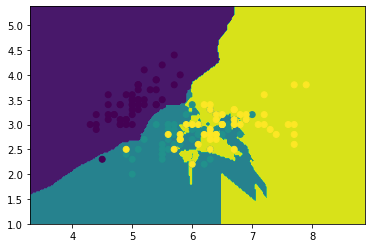

0.7894736842105263

In [10]:
plot(knn)
plt.scatter(x_data[:, 0], x_data[:, 1], c=y_data)
plt.show()
knn.score(x_test, y_test)

In [11]:
dtree = tree.DecisionTreeClassifier()
dtree.fit(x_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

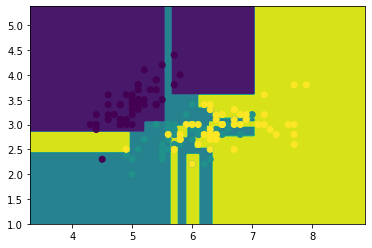

0.6578947368421053

In [12]:
plot(dtree)
plt.scatter(x_data[:,0], x_data[:,1], c=y_data)
plt.show()
dtree.score(x_test, y_test)

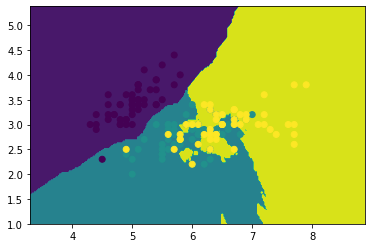

0.7894736842105263

In [14]:
bagging_knn = BaggingClassifier(knn, n_estimators=100)
# 输入数据建立模型
bagging_knn.fit(x_train, y_train)
plot(bagging_knn)
plt.scatter(x_data[:,0],x_data[:,1],c=y_data)
plt.show()
bagging_knn.score(x_test,y_test)

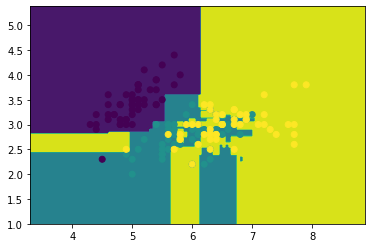

0.7368421052631579

In [15]:
bagging_tree = BaggingClassifier(dtree, n_estimators=100)
# 输入数据建立模型
bagging_tree.fit(x_train, y_train)
plot(bagging_tree)
plt.scatter(x_data[:,0],x_data[:,1],c=y_data)
plt.show()
bagging_tree.score(x_test,y_test)

## RF-随机森林
1. 样本的随机：从样本集中用bagging的方式，随机选择
n个样本

2. 特征的随机：从所有属性d中随机选择k个属性(k<d),然后从k个属性中选择最佳分割属性作为节点建立CART决策树

3. 重复以上两个步骤m次，建立m棵CART决策树

4. 这m棵CART决策树形成随机森林，通过投票表决结果，决定数据属于哪一类

In [16]:
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt


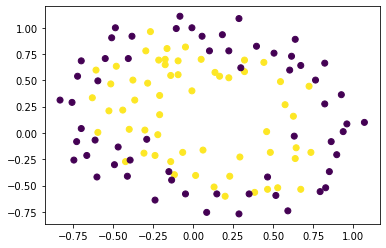

In [18]:
data = np.genfromtxt('LR-testSet2.txt', delimiter=',')
x_data = data[:,:-1]
y_data = data[:,-1]

plt.scatter(x_data[:,0], x_data[:,1], c=y_data)
plt.show()

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.5)

In [35]:
def plot(model):
  x_min, x_max = x_data[:, 0].min() - 1, x_data[:, 0].max() + 1
  y_min, y_max = x_data[:, 1].min() - 1, x_data[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                       np.arange(y_min, y_max, 0.02))
  z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  z = z.reshape(xx.shape)
  cs = plt.contourf(xx, yy, z)
  plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test)
  plt.show()

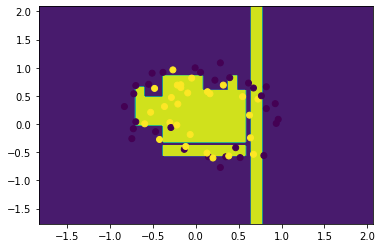

0.7627118644067796

In [36]:
dtree = tree.DecisionTreeClassifier()
dtree.fit(x_train, y_train)
plot(dtree)
dtree.score(x_test,y_test)

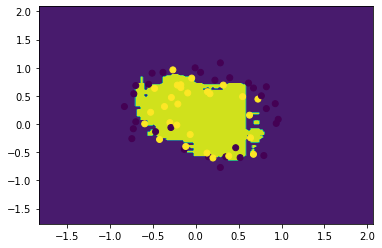

0.8135593220338984

In [37]:
RF = RandomForestClassifier(n_estimators=50)
RF.fit(x_train, y_train)
plot(RF)
RF.score(x_test, y_test)

## boosting
AdaBoost是英文"Adaptive Boosting"(自适应增强)的缩写，它的自适应在于：前一个基本分类器被错误分类的样本的权值会增大，而正确分类的样本的权值会减小，并两次用来训练下一个基本分类器。同时，在每一轮迭代中，加入一个新的弱分类器，直到达到某个预定的足够小的错误率或达到预先指定的最大迭代次数才确定最终的强分类器

直觉：将学习器的重点放在"容易"出错的样本上。可以提升学习器的性能


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_gaussian_quantiles
from sklearn.metrics import classification_report

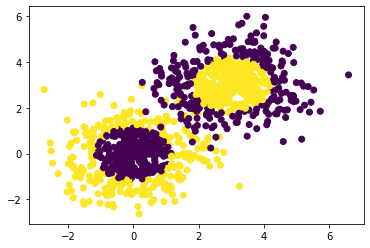

In [44]:
# 生成二维正态分布，生成的数据按分位数分两类
x1, y1 = make_gaussian_quantiles(n_samples=500, n_features=2, n_classes=2)
x2, y2 = make_gaussian_quantiles(mean=(3,3), n_samples=500, n_features=2, n_classes=2)

x_data = np.concatenate((x1,x2))
y_data = np.concatenate((y1,-y2+1))

plt.scatter(x_data[:, 0],x_data[:,1], c=y_data)
plt.show()

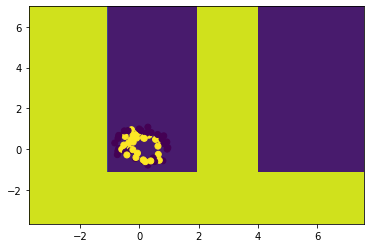

0.793

In [46]:
model = DecisionTreeClassifier(max_depth=3)

model.fit(x_data, y_data)

x_min, x_max = x_data[:, 0].min() - 1, x_data[:, 0].max() + 1
y_min, y_max = x_data[:, 1].min() - 1, x_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
z = model.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)
cs = plt.contourf(xx, yy, z)
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test)
plt.show()
model.score(x_data, y_data)

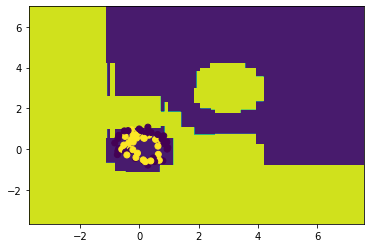

0.983

In [51]:
model = AdaBoostClassifier(DecisionTreeClassifier(max_depth=3), n_estimators=10)
model.fit(x_data, y_data)

x_min, x_max = x_data[:, 0].min() - 1, x_data[:, 0].max() + 1
y_min, y_max = x_data[:, 1].min() - 1, x_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
z = model.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)
cs = plt.contourf(xx, yy, z)
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test)
plt.show()
model.score(x_data, y_data)
model.score(x_data, y_data)

## Stacking
使用多个不同的分类器对训练集进行预测，把预测得到的结果，作为一个次级分类器的输入。次级分类器的输出是整个模型的预测结果。

In [66]:
from sklearn import datasets,model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from mlxtend.classifier import StackingClassifier
import numpy as np

In [67]:
iris = datasets.load_iris()
x_data, y_data = iris.data[:, 1:3], iris.target

clf1 = KNeighborsClassifier(n_neighbors=1)
clf2 = DecisionTreeClassifier()
clf3 = LogisticRegression()

lr = LogisticRegression()
sclf = StackingClassifier(classifiers = [clf1,clf2,clf3], meta_classifier=lr)

for clf,label in zip([clf1, clf2, clf3, sclf],['KNN','Decision Tree', 'LogisticRegression', 'StackingClassifier']):
  scores = model_selection.cross_val_score(clf, x_data, y_data, cv=3,scoring='accuracy')
  print("Accuracy:%0.2f [%s]" % (scores.mean(), label))

Accuracy:0.91 [KNN]
Accuracy:0.93 [Decision Tree]
Accuracy:0.95 [LogisticRegression]
Accuracy:0.95 [StackingClassifier]


## Voting

In [68]:
from sklearn import datasets, model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
import numpy as np

In [75]:
iris = datasets.load_iris()
x_data, y_data = iris.data[:, 1:3], iris.target

clf1 = KNeighborsClassifier(n_neighbors=1)
clf2 = DecisionTreeClassifier()
clf3 = LogisticRegression()

lr = LogisticRegression()
vot = VotingClassifier([('knn',clf1),('dtree',clf2),('lr',clf3)])

for clf,label in zip([clf1, clf2, clf3, vot],['KNN','Decision Tree', 'LogisticRegression', 'VotingClassifier']):
  scores = model_selection.cross_val_score(clf, x_data, y_data, cv=3,scoring='accuracy')
  print("Accuracy:%0.2f [%s]" % (scores.mean(), label))

Accuracy:0.91 [KNN]
Accuracy:0.91 [Decision Tree]
Accuracy:0.95 [LogisticRegression]
Accuracy:0.95 [VotingClassifier]
